# Модель Пуассона с xG

In [1]:
import os
import glob
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
from scipy.optimize import minimize_scalar

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120
})

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## 1. Конфигурация загрузки и параметров


In [ ]:
DATA_ROOT = Path('.')

LEAGUES = {
    'BL':  {
        'name': 'Бундеслига',
        'path': DATA_ROOT / 'data' / 'BL' / '*.csv',
        'xg_files': ['XG_2024_25.csv', 'XG_2025_26.csv']
    },
}

TEST_MATCHES_COUNT = 300
MIN_TRAIN_SIZE = 300
RETRAIN_EVERY = 10
ALPHA_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0]
MAX_GOALS = 10
DC_ALPHA_VALUES = [0.0, 0.5, 1.0]


def resolve_xg_paths(xg_files, league_code='BL'):
    if not xg_files:
        return []

    candidates = []
    for f in xg_files:
        f = Path(f)
        candidates.extend([
            DATA_ROOT / f,
            DATA_ROOT / 'data' / league_code / f.name,
            Path('/mnt/data') / f.name,
        ])

    resolved = []
    seen = set()
    for p in candidates:
        if p.exists():
            resolved_path = str(p.resolve())
            if resolved_path not in seen:
                resolved.append(p)
                seen.add(resolved_path)

    return resolved


## 2. Загрузка данных


In [3]:
def parse_football_date(series):
    parsed = pd.to_datetime(series, dayfirst=True, errors='coerce')
    if parsed.isna().mean() > 0.2:
        parsed = pd.to_datetime(series, errors='coerce')
    return parsed.dt.normalize()


def load_base_data(info):
    files = sorted(glob.glob(str(info['path'])))
    files = [f for f in files if not Path(f).name.upper().startswith('XG_')]

    frames = []
    required = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']
    odds_cols = ['B365H', 'B365D', 'B365A']

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f'  Не удалось прочитать {f}: {e}')
            continue

        if not set(required).issubset(df.columns):
            continue

        cols = required + [c for c in odds_cols if c in df.columns]
        part = df[cols].copy()
        part['source_file'] = Path(f).name
        frames.append(part)

    if not frames:
        raise FileNotFoundError(
            f"Не найдены football-data CSV по пути {info['path']}. "
            "Проверь DATA_ROOT и структуру папок."
        )

    data = pd.concat(frames, ignore_index=True)
    data = data.dropna(subset=['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']).copy()

    data['Date'] = parse_football_date(data['Date'])
    data['FTHG'] = pd.to_numeric(data['FTHG'], errors='coerce').astype('Int64')
    data['FTAG'] = pd.to_numeric(data['FTAG'], errors='coerce').astype('Int64')

    data = data.dropna(subset=['Date', 'FTHG', 'FTAG']).copy()
    data['FTHG'] = data['FTHG'].astype(int)
    data['FTAG'] = data['FTAG'].astype(int)

    data['HomeTeam'] = data['HomeTeam'].astype(str).str.strip()
    data['AwayTeam'] = data['AwayTeam'].astype(str).str.strip()

    data = data.sort_values(['Date', 'HomeTeam', 'AwayTeam']).reset_index(drop=True)
    return data


def load_xg_data(xg_files, league_code='BL'):
    paths = resolve_xg_paths(xg_files, league_code=league_code)
    if not paths:
        return None

    frames = []
    expected = ['date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'home_xg', 'away_xg']

    for path in paths:
        df = pd.read_csv(path)

        missing = [c for c in expected if c not in df.columns]
        if missing:
            raise ValueError(f'{path.name}: нет колонок {missing}')

        df = df[expected].copy()
        df['xg_source'] = path.name

        df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
        df['home_team'] = df['home_team'].astype(str).str.strip()
        df['away_team'] = df['away_team'].astype(str).str.strip()

        for col in ['home_goals', 'away_goals']:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

        for col in ['home_xg', 'away_xg']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        frames.append(df)

    xg = pd.concat(frames, ignore_index=True)
    xg = xg.dropna(subset=expected).copy()
    xg['home_goals'] = xg['home_goals'].astype(int)
    xg['away_goals'] = xg['away_goals'].astype(int)

    xg = xg.drop_duplicates(
        subset=['date', 'home_team', 'away_team', 'home_goals', 'away_goals'],
        keep='last'
    )
    xg = xg.sort_values(['date', 'home_team', 'away_team']).reset_index(drop=True)
    return xg


def merge_xg(base_df, xg_df):
    data = base_df.copy()

    if xg_df is None or len(xg_df) == 0:
        data['home_xg'] = np.nan
        data['away_xg'] = np.nan
        data['xg_source'] = np.nan
        return data

    xg_prepared = xg_df.rename(columns={
        'date': 'Date',
        'home_team': 'HomeTeam',
        'away_team': 'AwayTeam',
        'home_goals': 'FTHG',
        'away_goals': 'FTAG',
    })

    data = data.merge(
        xg_prepared[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'home_xg', 'away_xg', 'xg_source']],
        on=['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'],
        how='left'
    )

    data = data.sort_values(['Date', 'HomeTeam', 'AwayTeam']).reset_index(drop=True)
    return data


all_data = {}

for code_name, info in LEAGUES.items():
    base = load_base_data(info)
    xg = load_xg_data(info.get('xg_files'), league_code=code_name)
    data = merge_xg(base, xg)

    all_data[code_name] = data

    n_test = min(TEST_MATCHES_COUNT, len(data) - MIN_TRAIN_SIZE)
    print(f"{info['name']:15s}: {len(data)} матчей, тест: {n_test}")


Бундеслига     : 1458 матчей, тест: 300


## 3. Средние значения, корреляция голов с xG, распределение




Бундеслига: 539 матчей с xG из 1458 всего

Статистика голов vs xG:
  Ср. голов дома:  1.675
  Ср. xG дома:     1.813
  Ср. голов гости: 1.462
  Ср. xG гости:    1.448

  Корр. голов и xG (дом):   0.6370
  Корр. голов и xG (гости): 0.6451


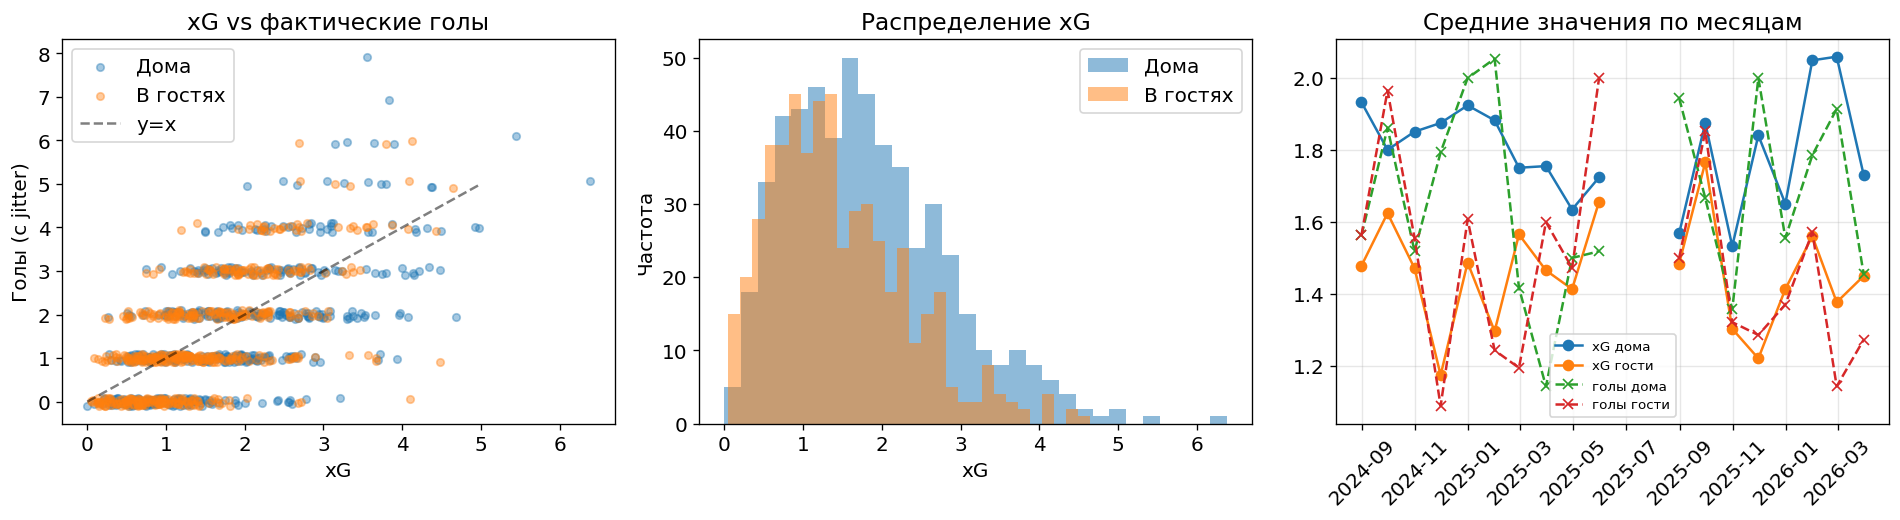

In [4]:
bl_data = all_data['BL'].copy()
bl_with_xg = bl_data.dropna(subset=['home_xg', 'away_xg']).copy()

print(f"Бундеслига: {len(bl_with_xg)} матчей с xG из {len(bl_data)} всего")
print()
print('Статистика голов vs xG:')
print(f"  Ср. голов дома:  {bl_with_xg['FTHG'].mean():.3f}")
print(f"  Ср. xG дома:     {bl_with_xg['home_xg'].mean():.3f}")
print(f"  Ср. голов гости: {bl_with_xg['FTAG'].mean():.3f}")
print(f"  Ср. xG гости:    {bl_with_xg['away_xg'].mean():.3f}")
print()
print(f"  Корр. голов и xG (дом):   {bl_with_xg['FTHG'].corr(bl_with_xg['home_xg']):.4f}")
print(f"  Корр. голов и xG (гости): {bl_with_xg['FTAG'].corr(bl_with_xg['away_xg']):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(bl_with_xg['home_xg'], bl_with_xg['FTHG'] + np.random.uniform(-0.1, 0.1, len(bl_with_xg)), alpha=0.4, s=20, label='Дома')
ax.scatter(bl_with_xg['away_xg'], bl_with_xg['FTAG'] + np.random.uniform(-0.1, 0.1, len(bl_with_xg)), alpha=0.4, s=20, label='В гостях')
ax.plot([0, 5], [0, 5], 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('xG')
ax.set_ylabel('Голы (с jitter)')
ax.set_title('xG vs фактические голы')
ax.legend()

ax = axes[1]
ax.hist(bl_with_xg['home_xg'], bins=30, alpha=0.5, label='Дома')
ax.hist(bl_with_xg['away_xg'], bins=30, alpha=0.5, label='В гостях')
ax.set_xlabel('xG')
ax.set_ylabel('Частота')
ax.set_title('Распределение xG')
ax.legend()

ax = axes[2]
monthly = bl_with_xg.set_index('Date')[['home_xg', 'away_xg', 'FTHG', 'FTAG']].resample('M').mean()
ax.plot(monthly.index, monthly['home_xg'], marker='o', label='xG дома')
ax.plot(monthly.index, monthly['away_xg'], marker='o', label='xG гости')
ax.plot(monthly.index, monthly['FTHG'], marker='x', linestyle='--', label='голы дома')
ax.plot(monthly.index, monthly['FTAG'], marker='x', linestyle='--', label='голы гости')
ax.set_title('Средние значения по месяцам')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Метрики

In [5]:
def outcome_from_score(home_goals, away_goals):
    if home_goals > away_goals:
        return 'H'
    if home_goals == away_goals:
        return 'D'
    return 'A'


def score_probs_from_lambdas(lambda_home, lambda_away, max_goals=MAX_GOALS):
    hp = np.array([poisson.pmf(i, lambda_home) for i in range(max_goals + 1)])
    ap = np.array([poisson.pmf(i, lambda_away) for i in range(max_goals + 1)])
    matrix = np.outer(hp, ap)
    mass = matrix.sum()
    if mass > 0:
        matrix = matrix / mass
    return {
        'p_home': float(np.sum(np.tril(matrix, -1))),
        'p_draw': float(np.sum(np.diag(matrix))),
        'p_away': float(np.sum(np.triu(matrix, 1))),
    }


def compute_metrics(preds_df):
    n = len(preds_df)
    if n == 0:
        return {'N': 0, 'Accuracy': np.nan, 'Log-Loss': np.nan, 'Brier Score': np.nan, 'RPS': np.nan}

    p = preds_df[['p_home', 'p_draw', 'p_away']].values
    a = np.zeros((n, 3))
    for i, o in enumerate(preds_df['actual']):
        if o == 'H':
            a[i, 0] = 1
        elif o == 'D':
            a[i, 1] = 1
        else:
            a[i, 2] = 1

    acc = np.mean(np.argmax(p, axis=1) == np.argmax(a, axis=1))
    ll = -np.mean(np.sum(a * np.log(np.clip(p, 1e-12, 1)), axis=1))
    bs = np.mean(np.sum((p - a) ** 2, axis=1))
    rps = np.mean(np.sum((np.cumsum(p[:, :2], axis=1) - np.cumsum(a[:, :2], axis=1)) ** 2, axis=1) / 2)

    return {'N': n, 'Accuracy': acc, 'Log-Loss': ll, 'Brier Score': bs, 'RPS': rps}


def bookmaker_metrics(preds_df):
    if not {'B365H', 'B365D', 'B365A'}.issubset(preds_df.columns):
        return None
    df = preds_df.dropna(subset=['B365H', 'B365D', 'B365A']).copy()
    if len(df) == 0:
        return None

    total_implied = 1 / df['B365H'] + 1 / df['B365D'] + 1 / df['B365A']
    df['fh'] = (1 / df['B365H']) / total_implied
    df['fd'] = (1 / df['B365D']) / total_implied
    df['fa'] = (1 / df['B365A']) / total_implied

    n = len(df)
    a = np.zeros((n, 3))
    for i, o in enumerate(df['actual']):
        if o == 'H':
            a[i, 0] = 1
        elif o == 'D':
            a[i, 1] = 1
        else:
            a[i, 2] = 1

    p = np.clip(df[['fh', 'fd', 'fa']].values, 1e-12, 1)
    ll = -np.mean(np.sum(a * np.log(p), axis=1))
    bs = np.mean(np.sum((p - a) ** 2, axis=1))
    rps = np.mean(np.sum((np.cumsum(p[:, :2], axis=1) - np.cumsum(a[:, :2], axis=1)) ** 2, axis=1) / 2)
    return {'N': n, 'Bookmaker Log-Loss': ll, 'Bookmaker Brier': bs, 'Bookmaker RPS': rps}

## 5. Модель Пуассона: смешение голов и xG

In [ ]:
def train_goals_model(train_data):
    goal_data = pd.concat([
        train_data[['HomeTeam', 'AwayTeam', 'FTHG']].assign(home=1).rename(
            columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'FTHG': 'goals'}),
        train_data[['AwayTeam', 'HomeTeam', 'FTAG']].assign(home=0).rename(
            columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'FTAG': 'goals'})
    ], ignore_index=True)
    return smf.glm('goals ~ home + team + opponent', data=goal_data, family=sm.families.Poisson()).fit()


def train_xg_glm_model(train_data, min_matches=50):
    df = train_data.dropna(subset=['home_xg', 'away_xg']).copy()
    if len(df) < min_matches:
        return None

    xg_data = pd.concat([
        df[['HomeTeam', 'AwayTeam', 'home_xg']].assign(home=1).rename(
            columns={'HomeTeam': 'team', 'AwayTeam': 'opponent', 'home_xg': 'xg'}),
        df[['AwayTeam', 'HomeTeam', 'away_xg']].assign(home=0).rename(
            columns={'AwayTeam': 'team', 'HomeTeam': 'opponent', 'away_xg': 'xg'})
    ], ignore_index=True)
    xg_data = xg_data[xg_data['xg'].ge(0)].copy()
    return smf.glm('xg ~ home + team + opponent', data=xg_data, family=sm.families.Poisson()).fit()


def predict_lambda(model, home_team, away_team):
    if model is None:
        return None, None
    try:
        home_df = pd.DataFrame({'team': [home_team], 'opponent': [away_team], 'home': [1]})
        away_df = pd.DataFrame({'team': [away_team], 'opponent': [home_team], 'home': [0]})
        lambda_home = float(model.predict(home_df).iloc[0])
        lambda_away = float(model.predict(away_df).iloc[0])
        return lambda_home, lambda_away
    except Exception:
        return None, None


def predict_blended(goals_model, xg_model, home_team, away_team, alpha, max_goals=MAX_GOALS):
    lh_g, la_g = predict_lambda(goals_model, home_team, away_team)
    if lh_g is None or la_g is None:
        return None

    if xg_model is None or alpha == 1.0:
        lh, la = lh_g, la_g
        lh_x, la_x = np.nan, np.nan
    else:
        lh_x, la_x = predict_lambda(xg_model, home_team, away_team)
        if lh_x is None or la_x is None:
            lh, la = lh_g, la_g
            lh_x, la_x = np.nan, np.nan
        else:
            lh = alpha * lh_g + (1 - alpha) * lh_x
            la = alpha * la_g + (1 - alpha) * la_x

    probs = score_probs_from_lambdas(lh, la, max_goals=max_goals)
    return {
        **probs,
        'lambda_home': lh,
        'lambda_away': la,
        'lambda_home_goals': lh_g,
        'lambda_away_goals': la_g,
        'lambda_home_xg_glm': lh_x,
        'lambda_away_xg_glm': la_x,
    }


def rolling_backtest_blended(data, n_test, alpha, retrain_every=RETRAIN_EVERY, min_train=MIN_TRAIN_SIZE):
    n = len(data)
    split_start = max(n - n_test, min_train)

    results = []
    goals_model = None
    xg_model = None
    last_train_idx = -1

    for i in range(split_start, n):
        if goals_model is None or (i - last_train_idx) >= retrain_every:
            train_data = data.iloc[:i].copy()
            try:
                goals_model = train_goals_model(train_data)
                xg_model = train_xg_glm_model(train_data) if alpha < 1.0 else None
                last_train_idx = i
            except Exception:
                continue

        row = data.iloc[i]
        pred = predict_blended(goals_model, xg_model, row['HomeTeam'], row['AwayTeam'], alpha)
        if pred is None:
            continue

        result = {
            'Date': row['Date'],
            'HomeTeam': row['HomeTeam'],
            'AwayTeam': row['AwayTeam'],
            'FTHG': row['FTHG'],
            'FTAG': row['FTAG'],
            'actual': outcome_from_score(row['FTHG'], row['FTAG']),
            'model': f'lambda_blend_alpha_{alpha}',
            **pred,
        }
        for col in ['B365H', 'B365D', 'B365A']:
            if col in data.columns and pd.notna(row.get(col)):
                result[col] = row[col]
        results.append(result)

    return pd.DataFrame(results)

In [ ]:
data_bl = all_data['BL'].copy()
n_test = min(TEST_MATCHES_COUNT, len(data_bl) - MIN_TRAIN_SIZE)
print('alpha = 1.0: только голы | alpha = 0.0: только xG-GLM | промежуточные: смешивание\n')

alpha_results = {}
for alpha in ALPHA_VALUES:
    t0 = time.time()
    preds = rolling_backtest_blended(data_bl, n_test=n_test, alpha=alpha)
    elapsed = time.time() - t0
    alpha_results[alpha] = preds

alpha = 1.0: только голы | alpha = 0.0: только xG-GLM | промежуточные: смешивание


In [ ]:
blend_rows = []
for alpha, preds in alpha_results.items():
    m = compute_metrics(preds)
    m['model'] = 'lambda_blend'
    m['alpha'] = alpha
    m['Описание'] = {
        0.0: 'только xG',
        0.25: '0.75xG + 0.25голы',
        0.5: 'равный вклад',
        0.75: '0.25xG + 0.75голы',
        1.0: 'только голы'
    }.get(alpha, '')
    blend_rows.append(m)

blend_table = pd.DataFrame(blend_rows)
blend_table = blend_table[['model', 'alpha', 'Описание', 'N', 'Accuracy', 'Log-Loss', 'Brier Score', 'RPS']]
for c in ['Accuracy', 'Log-Loss', 'Brier Score', 'RPS']:
    blend_table[c] = blend_table[c].round(4)

display(blend_table)

best_alpha = min(alpha_results.keys(), key=lambda a: compute_metrics(alpha_results[a])['Log-Loss'])
print(f'Лучший alpha по Log-Loss: {best_alpha}')

,model,alpha,Описание,N,Accuracy,Log-Loss,Brier Score,RPS
0,lambda_blend,0.00,только xG,298,0.5168,0.9877,0.5873,0.1980
1,lambda_blend,0.25,0.75xG + 0.25голы,298,0.5134,0.9840,0.5843,0.1968
2,lambda_blend,0.50,равный вклад,298,0.5201,0.9831,0.5831,0.1965
3,lambda_blend,0.75,0.25xG + 0.75голы,298,0.5201,0.9857,0.5839,0.1971
4,lambda_blend,1.00,только голы,298,0.5168,1.0535,0.5867,0.1987


Лучший alpha по Log-Loss: 0.5


## 6. Модель 2: классический Dixon-Coles c xG

In [ ]:
def dc_rho_bounds(lambda_home, lambda_away, eps=1e-8):
    lh = np.clip(np.asarray(lambda_home, dtype=float), 1e-8, None)
    la = np.clip(np.asarray(lambda_away, dtype=float), 1e-8, None)

    lower = max(np.max(-1.0 / lh), np.max(-1.0 / la)) + eps
    upper = min(np.min(1.0 / (lh * la)), 1.0) - eps
    return lower, upper


def dc_tau_values(home_goals, away_goals, lambda_home, lambda_away, rho):
    x = np.asarray(home_goals)
    y = np.asarray(away_goals)
    lh = np.asarray(lambda_home, dtype=float)
    la = np.asarray(lambda_away, dtype=float)

    tau = np.ones(len(x), dtype=float)

    mask_00 = (x == 0) & (y == 0)
    mask_01 = (x == 0) & (y == 1)
    mask_10 = (x == 1) & (y == 0)
    mask_11 = (x == 1) & (y == 1)

    tau[mask_00] = 1.0 - lh[mask_00] * la[mask_00] * rho
    tau[mask_01] = 1.0 + lh[mask_01] * rho
    tau[mask_10] = 1.0 + la[mask_10] * rho
    tau[mask_11] = 1.0 - rho

    return tau


def estimate_rho_for_blended_lambdas(train_lambdas, min_matches=80):
    if train_lambdas is None or len(train_lambdas) < min_matches:
        return 0.0

    df = train_lambdas.dropna(subset=['FTHG', 'FTAG', 'lambda_home', 'lambda_away']).copy()
    if len(df) < min_matches:
        return 0.0

    lower, upper = dc_rho_bounds(df['lambda_home'].values, df['lambda_away'].values)
    if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        return 0.0

    def objective(rho):
        tau = dc_tau_values(
            df['FTHG'].values,
            df['FTAG'].values,
            df['lambda_home'].values,
            df['lambda_away'].values,
            rho
        )
        if np.any(tau <= 0) or np.any(~np.isfinite(tau)):
            return 1e9
        return -float(np.sum(np.log(tau)))

    try:
        res = minimize_scalar(objective, bounds=(lower, upper), method='bounded', options={'xatol': 1e-5})
        if res.success and np.isfinite(res.x):
            return float(res.x)
    except Exception:
        pass

    return 0.0


def clip_rho_for_match(lambda_home, lambda_away, rho):
    lower, upper = dc_rho_bounds([lambda_home], [lambda_away])
    if lower >= upper:
        return 0.0
    return float(np.clip(rho, lower, upper))


def dc_score_probs_from_lambdas(lambda_home, lambda_away, rho, max_goals=MAX_GOALS):
    rho_used = clip_rho_for_match(lambda_home, lambda_away, rho)

    hp = np.array([poisson.pmf(i, lambda_home) for i in range(max_goals + 1)])
    ap = np.array([poisson.pmf(i, lambda_away) for i in range(max_goals + 1)])
    matrix = np.outer(hp, ap)

    matrix[0, 0] *= (1.0 - lambda_home * lambda_away * rho_used)
    matrix[0, 1] *= (1.0 + lambda_home * rho_used)
    matrix[1, 0] *= (1.0 + lambda_away * rho_used)
    matrix[1, 1] *= (1.0 - rho_used)

    if np.any(matrix < 0) or not np.isfinite(matrix).all():
        return None

    mass = matrix.sum()
    if mass <= 0:
        return None
    matrix = matrix / mass

    return {
        'p_home': float(np.sum(np.tril(matrix, -1))),
        'p_draw': float(np.sum(np.diag(matrix))),
        'p_away': float(np.sum(np.triu(matrix, 1))),
        'rho_used': rho_used,
    }


def build_train_lambdas_for_rho(train_data, goals_model, xg_model, alpha):
    if alpha < 1.0:
        rho_train_data = train_data.dropna(subset=['home_xg', 'away_xg']).copy()
    else:
        rho_train_data = train_data.copy()

    rows = []
    for _, row in rho_train_data.iterrows():
        pred = predict_blended(
            goals_model,
            xg_model,
            row['HomeTeam'],
            row['AwayTeam'],
            alpha=alpha
        )
        if pred is None:
            continue

        rows.append({
            'FTHG': row['FTHG'],
            'FTAG': row['FTAG'],
            'lambda_home': pred['lambda_home'],
            'lambda_away': pred['lambda_away'],
        })

    return pd.DataFrame(rows)


def predict_dc_blended(goals_model, xg_model, row, alpha, rho, max_goals=MAX_GOALS):
    base_pred = predict_blended(
        goals_model,
        xg_model,
        row['HomeTeam'],
        row['AwayTeam'],
        alpha=alpha,
        max_goals=max_goals
    )
    if base_pred is None:
        return None

    dc_probs = dc_score_probs_from_lambdas(
        base_pred['lambda_home'],
        base_pred['lambda_away'],
        rho=rho,
        max_goals=max_goals
    )
    if dc_probs is None:
        return None

    return {
        **dc_probs,
        'lambda_home': base_pred['lambda_home'],
        'lambda_away': base_pred['lambda_away'],
        'lambda_home_goals': base_pred['lambda_home_goals'],
        'lambda_away_goals': base_pred['lambda_away_goals'],
        'lambda_home_xg_glm': base_pred['lambda_home_xg_glm'],
        'lambda_away_xg_glm': base_pred['lambda_away_xg_glm'],
    }


def rolling_backtest_dc_xg_blend(data, n_test, alpha, retrain_every=RETRAIN_EVERY, min_train=MIN_TRAIN_SIZE):
    n = len(data)
    split_start = max(n - n_test, min_train)

    results = []
    goals_model = None
    xg_model = None
    rho = 0.0
    last_train_idx = -1

    for i in range(split_start, n):
        if goals_model is None or (i - last_train_idx) >= retrain_every:
            train_data = data.iloc[:i].copy()
            try:
                goals_model = train_goals_model(train_data)
                xg_model = train_xg_glm_model(train_data) if alpha < 1.0 else None

                train_lambdas = build_train_lambdas_for_rho(train_data, goals_model, xg_model, alpha)
                rho = estimate_rho_for_blended_lambdas(train_lambdas)

                last_train_idx = i
            except Exception:
                continue

        row = data.iloc[i]
        pred = predict_dc_blended(goals_model, xg_model, row, alpha=alpha, rho=rho)
        if pred is None:
            continue

        result = {
            'Date': row['Date'],
            'HomeTeam': row['HomeTeam'],
            'AwayTeam': row['AwayTeam'],
            'FTHG': row['FTHG'],
            'FTAG': row['FTAG'],
            'actual': outcome_from_score(row['FTHG'], row['FTAG']),
            'model': f'dc_xg_blend_alpha_{alpha}',
            'rho_train': rho,
            **pred,
        }
        for col in ['B365H', 'B365D', 'B365A']:
            if col in data.columns and pd.notna(row.get(col)):
                result[col] = row[col]
        results.append(result)

    return pd.DataFrame(results)


In [ ]:
dc_alpha_values = sorted(set(DC_ALPHA_VALUES + [best_alpha]))

print('Тест Диксона-Коулса поверх lambda-смешивания')
print('alpha = 1.0: DC поверх goal | alpha = 0.0: DC поверх xG | alpha = 0.5: DC поверх равного смешивания\n')

dc_xg_results = {}
for alpha in dc_alpha_values:
    t0 = time.time()
    preds = rolling_backtest_dc_xg_blend(data_bl, n_test=n_test, alpha=alpha)
    dc_xg_results[alpha] = preds

    rho_mean = preds['rho_train'].mean() if len(preds) and 'rho_train' in preds.columns else np.nan
    print(f'  alpha={alpha}: {len(preds)} предсказаний | средний p={rho_mean:.4f}')


Тест Диксона-Коулса поверх lambda-смешивания
alpha = 1.0: DC поверх goal | alpha = 0.0: DC поверх xG | alpha = 0.5: DC поверх равного смешивания

  alpha=0.0: 298 предсказаний | средний p=-0.0869
  alpha=0.5: 298 предсказаний | средний p=-0.0959
  alpha=1.0: 298 предсказаний | средний p=-0.1269


In [ ]:
dc_rows = []
for alpha, preds in dc_xg_results.items():
    m = compute_metrics(preds)
    m['model'] = 'dc_xg_blend'
    m['alpha'] = alpha
    m['Описание'] = {
        0.0: 'DC + только xG-lambda',
        0.5: 'DC + равный goal/xG blend',
        1.0: 'DC + только goal-lambda'
    }.get(alpha, 'DC + выбранный blend')
    if len(preds) and 'rho_train' in preds.columns:
        m['mean_rho'] = preds['rho_train'].mean()
    else:
        m['mean_rho'] = np.nan
    dc_rows.append(m)

dc_xg_table = pd.DataFrame(dc_rows)
dc_xg_table = dc_xg_table[['model', 'alpha', 'Описание', 'N', 'Accuracy', 'Log-Loss', 'Brier Score', 'RPS', 'mean_rho']]
for c in ['Accuracy', 'Log-Loss', 'Brier Score', 'RPS', 'mean_rho']:
    dc_xg_table[c] = dc_xg_table[c].round(4)

display(dc_xg_table)

best_dc_alpha = min(dc_xg_results.keys(), key=lambda a: compute_metrics(dc_xg_results[a])['Log-Loss'])
print(f'Лучший alpha для DC+xG по Log-Loss: {best_dc_alpha}')

# Прямое сравнение: добавляет ли DC что-то к обычному λ-blend при тех же α.
paired_rows = []
for alpha in dc_xg_results:
    if alpha in alpha_results:
        m_pois = compute_metrics(alpha_results[alpha])
        m_dc = compute_metrics(dc_xg_results[alpha])
        paired_rows.append({
            'alpha': alpha,
            'Poisson/blend LL': m_pois['Log-Loss'],
            'DC+xG LL': m_dc['Log-Loss'],
            'delta LL = DC - Poisson': m_dc['Log-Loss'] - m_pois['Log-Loss'],
            'Poisson/blend Brier': m_pois['Brier Score'],
            'DC+xG Brier': m_dc['Brier Score'],
            'delta Brier = DC - Poisson': m_dc['Brier Score'] - m_pois['Brier Score'],
        })

paired_dc_comparison = pd.DataFrame(paired_rows).sort_values('alpha')
display(paired_dc_comparison.round(5))


,model,alpha,Описание,N,Accuracy,Log-Loss,Brier Score,RPS,mean_rho
0,dc_xg_blend,0.0,DC + только xG-lambda,298,0.5168,0.9841,0.5854,0.1977,-0.0869
1,dc_xg_blend,0.5,DC + равный goal/xG blend,298,0.5201,0.9795,0.5812,0.1962,-0.0959
2,dc_xg_blend,1.0,DC + только goal-lambda,298,0.5134,1.0505,0.5849,0.1984,-0.1269


Лучший alpha для DC+xG по Log-Loss: 0.5


,alpha,Poisson/blend LL,DC+xG LL,delta LL = DC - Poisson,Poisson/blend Brier,DC+xG Brier,delta Brier = DC - Poisson
0,0.0,0.98774,0.98413,-0.00361,0.58726,0.58537,-0.00189
1,0.5,0.98306,0.97950,-0.00356,0.58311,0.58120,-0.00190
2,1.0,1.05348,1.05054,-0.00294,0.58669,0.58485,-0.00184


## 8. Сводное сравнение: blend, DC+xG, xG-form, букмекер

Сравнение лучше делать на общем пересечении матчей, чтобы не получилось, что одна модель оценивается на 300 матчах, а другая — на другом наборе.

In [ ]:
def add_match_id(df):
    out = df.copy()
    out['match_id'] = (
        out['Date'].astype(str) + '|' + out['HomeTeam'].astype(str) + '|' + out['AwayTeam'].astype(str)
    )
    return out

all_pred_sets = []

# 1) Poisson
for alpha, preds in alpha_results.items():
    all_pred_sets.append(add_match_id(preds.assign(model=f'lambda_blend_alpha_{alpha}')))

# 2) Dixon-Coles
if 'dc_xg_results' in globals():
    for alpha, preds in dc_xg_results.items():
        all_pred_sets.append(add_match_id(preds.assign(model=f'dc_xg_blend_alpha_{alpha}')))

combined_preds = pd.concat(all_pred_sets, ignore_index=True) if all_pred_sets else pd.DataFrame()

summary_rows = []
for model_name, g in combined_preds.groupby('model'):
    m = compute_metrics(g)
    m['model'] = model_name
    summary_rows.append(m)
summary = pd.DataFrame(summary_rows)
summary = summary[['model', 'N', 'Accuracy', 'Log-Loss', 'Brier Score', 'RPS']].sort_values('Log-Loss')
display(summary.round(4))

# Букмекерская линия на матчах лучшего
bk_rows = []

bk = bookmaker_metrics(alpha_results[best_alpha])
if bk is not None:
    bk_rows.append({'model': f'bookmaker_on_lambda_blend_alpha_{best_alpha}', **bk})

if 'best_dc_alpha' in globals():
    bk_dc = bookmaker_metrics(dc_xg_results[best_dc_alpha])
    if bk_dc is not None:
        bk_rows.append({'model': f'bookmaker_on_dc_xg_alpha_{best_dc_alpha}', **bk_dc})

if bk_rows:
    print('\nБукмекерская линия на сопоставимых матчах:')
    display(pd.DataFrame(bk_rows).round(4))


,model,N,Accuracy,Log-Loss,Brier Score,RPS
1,dc_xg_blend_alpha_0.5,298,0.5201,0.9795,0.5812,0.1962
5,lambda_blend_alpha_0.5,298,0.5201,0.9831,0.5831,0.1965
4,lambda_blend_alpha_0.25,298,0.5134,0.9840,0.5843,0.1968
0,dc_xg_blend_alpha_0.0,298,0.5168,0.9841,0.5854,0.1977
6,lambda_blend_alpha_0.75,298,0.5201,0.9857,0.5839,0.1971
3,lambda_blend_alpha_0.0,298,0.5168,0.9877,0.5873,0.1980
2,dc_xg_blend_alpha_1.0,298,0.5134,1.0505,0.5849,0.1984
7,lambda_blend_alpha_1.0,298,0.5168,1.0535,0.5867,0.1987


,model,N,Accuracy,Log-Loss,Brier Score,RPS
2,dc_xg_blend_alpha_0.5,294,0.5204,0.9803,0.5817,0.1963
0,lambda_blend_alpha_0.5,294,0.5204,0.9839,0.5836,0.1966
1,lambda_blend_alpha_1.0,294,0.5170,1.0544,0.5865,0.1985



Букмекерская линия на сопоставимых матчах:


,model,N,Bookmaker Log-Loss,Bookmaker Brier,Bookmaker RPS
0,bookmaker_on_lambda_blend_alpha_0.5,298,0.9571,0.567,0.1895
1,bookmaker_on_dc_xg_alpha_0.5,298,0.9571,0.567,0.1895


## 9. Сохранение результатов

In [ ]:
output_dir = Path('outputs_xg')
output_dir.mkdir(exist_ok=True)

best_preds = alpha_results[best_alpha]
best_preds.to_csv(output_dir / f'predictions_poisson_xg_BL_alpha{best_alpha}.csv', index=False)
alpha_results[1.0].to_csv(output_dir / 'predictions_poisson_xg_BL_alpha1.0.csv', index=False)
alpha_results[0.0].to_csv(output_dir / 'predictions_poisson_xg_BL_alpha0.0.csv', index=False)

if 'dc_xg_results' in globals():
    for alpha, preds in dc_xg_results.items():
        preds.to_csv(output_dir / f'predictions_dc_xg_blend_BL_alpha{alpha}.csv', index=False)
    dc_xg_table.to_csv(output_dir / 'metrics_dc_xg_blend.csv', index=False)
    paired_dc_comparison.to_csv(output_dir / 'metrics_dc_vs_poisson_same_alpha.csv', index=False)


blend_table.to_csv(output_dir / 'metrics_lambda_blend.csv', index=False)
summary.to_csv(output_dir / 'metrics_all_models.csv', index=False)
bl_data.to_csv(output_dir / 'BL_with_xG_merged.csv', index=False)

print(f"- xG-покрытие: {bl_data['home_xg'].notna().sum()} матчей")
print(f"- лучший alpha для lambda-blend: {best_alpha}")
print(f"- LL лучшего lambda-blend: {compute_metrics(best_preds)['Log-Loss']:.4f}")
print(f"- LL чистых голов alpha=1.0: {compute_metrics(alpha_results[1.0])['Log-Loss']:.4f}")

if 'dc_xg_results' in globals():
    best_dc_preds = dc_xg_results[best_dc_alpha]
    print(f"- лучший alpha для DC+xG: {best_dc_alpha}")
    print(f"- LL лучшего DC+xG: {compute_metrics(best_dc_preds)['Log-Loss']:.4f}")
    print(f"- ΔLL лучшего DC+xG против лучшего λ-blend: {compute_metrics(best_dc_preds)['Log-Loss'] - compute_metrics(best_preds)['Log-Loss']:.4f}")

- xG-покрытие: 539 матчей
- лучший alpha для lambda-blend: 0.5
- LL лучшего lambda-blend: 0.9831
- LL чистых голов alpha=1.0: 1.0535
- лучший alpha для DC+xG: 0.5
- LL лучшего DC+xG: 0.9795
- delta LL лучшего DC+xG против лучшего lambda-blend: -0.0036
